# Ejercicio: simular y visualizar GPs

El objetivo es aprender a simular trayectorias de un GP, usando algunas de las herramientas más habituales de _machine learning_ (las que hemos visto: Python, Numpy, matplotlib). Como resultado final, generaremos las imágenes vistas en las diapositivas.

**Nota:** Si escribís sobre este notebook que os comparto, vuestros cambios no se guardarán (porque solo tenéis permisos de lectura). Igual que con el PAS, tendréis que crear una copia vuestra ("Archivo > Guardar una copia en Drive").

In [53]:
# Importamos librerías básicas que utilizaremos

import numpy as np
import matplotlib.pyplot as plt
import math

## 1. Muestras de una normal multivariante / multidimensional

Puesto que simular trayectorias de un GP involucra simular de una normal multivariante, veamos primero cómo hacer esto.

En la siguiente celda se deben obtener 50 muestras de una normal 3-dimensional $(X_1,X_2,X_3)$ que sigue una distribución normal $\mathcal{N}(0,I_{3\times 3})$

Para ello, utiliza la función `np.random.multivariate_normal` (busca en internet cómo usarla).

Además, visualiza el resultado obtenido, así como su shape.

In [54]:
# COMPLETAR!
# definimos el vector de medias - 3 dimensiones, todo ceros
vector_medias = np.zeros(3)
matriz_covarianzas = np.eye(3) # identidad
num_samples = 50
samples = np.random.multivariate_normal(mean=vector_medias, cov = matriz_covarianzas)

print("Shape: ", samples.shape)
print("Muestras: ")
print(samples)

Shape:  (3,)
Muestras: 
[ 0.85321769 -0.0925818   0.83495803]


Haz ahora lo mismo pero para una normal con matriz de covarianzas que no sea la identidad, sino por ejemplo $$\Sigma=\begin{pmatrix}1 & 0 & 0 \\
0 & 10 & 0 \\
0 & 0 & 100 \end{pmatrix}$$

Puedes simplificar algo el código si usas la función `np.diag`.

¿Qué diferencias esperarías ver en las muestras obtenidas?


In [55]:
# COMPLETAR!

vector_medias = np.zeros(3)
matriz_covarianzas = np.diag([1,10,100])
num_samples = 50
samples = np.random.multivariate_normal(mean=vector_medias, cov = matriz_covarianzas)

print("Shape: ", samples.shape)
print("Muestras: ")
print(samples)

Shape:  (3,)
Muestras: 
[ 0.19101316  2.69030831 -3.69438555]


## 2. Simular un GP con kernel RBF

En esta sección vamos a definir una función `simular_GP_RBF` que nos permita simular de un GP con kernel RBF. Y a continuación la usamos para generar imágenes similares a las de las diapositivas. Usaremos función de medias constantemente igual a cero.

En el punto 5 se explicará la manera más limpia de usar otras funciones de medias. También se comentará la manera más adecuada para pasar el kernel como argumento de la función. Es decir, de modo que no sea necesario definir `simular_GP_RBF`, sino simplemente `simular_GP` (y que el kernel se pase como argumento de la función). Todo ello necesita del concepto de _clases_, algo que (creo) no se estudia en el grado en matemáticas.

Definimos la función principal:

In [56]:
  # COMPLETAR
def simular_GP_RBF(t, sigma_sq=1, lengthscale=1, num_samples=1):
    """
    Simular un GP con kernel RBF.

    Input:
    t: vector de localizaciones en los que se quiere simular el GP. Numpy array de shape (n,).
    sigma_sq: varianza del kernel. Float.
    lengthscale: parámetro de escala del kernel. Float.
    num_samples: número de muestras a generar. Int.

    Output:
    samples: muestras del GP. Numpy array de shape (num_samples, n).
    """

    # Paso 1: calcula el vector de medias.
    # Esto crea un vector de ceros exactamente del mismo tamaño que 't'
    vector_medias = np.zeros_like(t)

    # Paso 2: calcula la matriz de covarianzas usando broadcasting.
    # t[:, np.newaxis] convierte el array 1D en un vector columna.
    # Al restarle 't' (vector fila), NumPy crea automáticamente una matriz NxN con todas las diferencias (t_i - t_j)
    diferencias = t[:, np.newaxis] - t
    distancias_cuadradas = diferencias ** 2

    # Aplicamos la fórmula del kernel RBF
    matriz_covs = sigma_sq * np.exp(-0.5 * distancias_cuadradas / (lengthscale ** 2))

    # Truco de estabilidad numérica (jitter) por si NumPy se pone exquisito
    matriz_covs = matriz_covs + 1e-8 * np.eye(len(t))

    # Paso 3: obtén las muestras/simulaciones del GP.
    # Usar matriz_covs (no matriz_covarianzas) y añadir size=num_samples

    samples = np.random.multivariate_normal(mean=vector_medias, cov=matriz_covs, size=num_samples)

    return samples



Ahora utilizamos esta función para generar imágenes similares a las de las diapositivas 59 y 62.

Para ello, genera las trayectorias con la función recién definida, `simular_GP_RBF`, y píntalas con `plt.plot`

Opcional: si quieres tener diferentes ejes (subplots) en la misma figura, como se hace en las diapositivas 59 y 62, puedes mirar cómo usar `plt.subplots`.

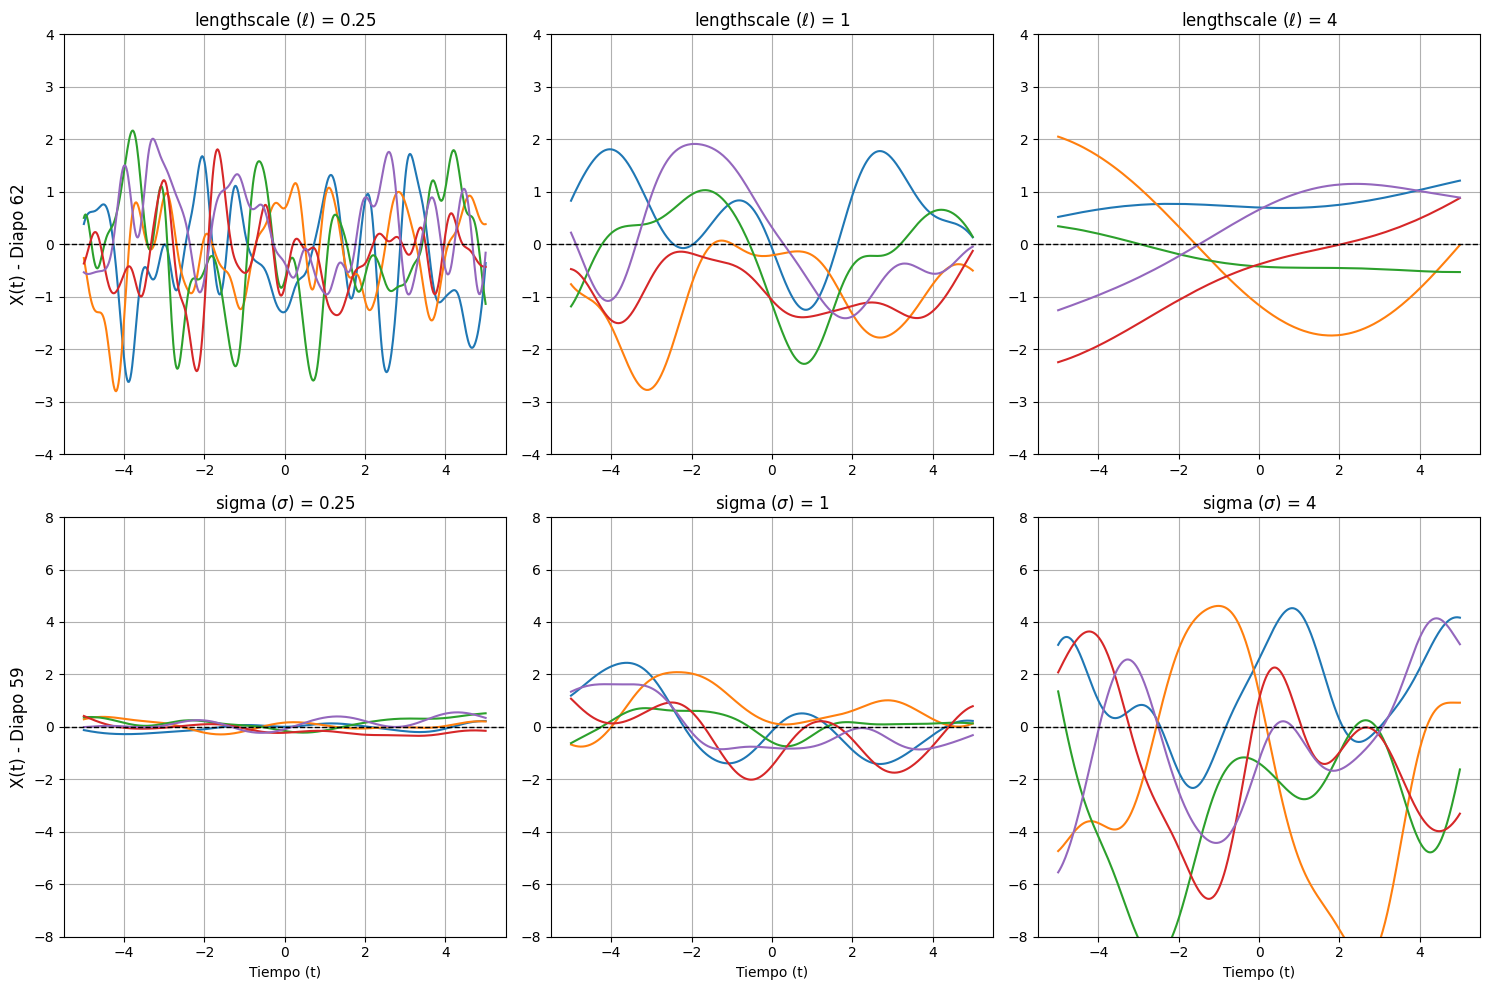

In [57]:
# 1. Definimos las variables base
t_grid = np.linspace(-5, 5, 500)
num_trayectorias = 5

# 2. CREAMOS EL LIENZO (2 filas, 3 columnas)
# Aumentamos el tamaño de la figura para que quepan todos los gráficos bien
fig, ax = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))

# ==============================================================================
# FILA 1: RECREANDO LA DIAPOSITIVA 62 (Efecto de Lengthscale con Sigma=1)
# ==============================================================================
lengthscales = [0.25, 1, 4] # Valores propuestos en la diapo 62

for j, l in enumerate(lengthscales):
    # Generamos muestras para este lengthscale específico (sigma_sq es fijo a 1)
    muestras = simular_GP_RBF(t_grid, sigma_sq=1**2, lengthscale=l, num_samples=num_trayectorias)

    # Dibujamos en la fila superior (ax[0, j])
    for i in range(num_trayectorias):
        ax[0, j].plot(t_grid, muestras[i, :])

    ax[0, j].set_title(fr'lengthscale ($\ell$) = {l}', fontsize=12)
    ax[0, j].axhline(0, color='black', linewidth=1, linestyle='--')
    ax[0, j].set_ylim(-4, 4) # Rango vertical fijo para comparar suavidad
    ax[0, j].grid(True)
    if j == 0: ax[0, j].set_ylabel('X(t) - Diapo 62', fontsize=12)

# ==============================================================================
# FILA 2: RECREANDO LA DIAPOSITIVA 59 (Efecto de Sigma con Lengthscale=1)
# ==============================================================================
sigmas = [0.25, 1, 4] # Valores propuestos en la diapo 59

for j, s in enumerate(sigmas):
    # Generamos muestras para este sigma específico (lengthscale es fijo a 1)
    muestras = simular_GP_RBF(t_grid, sigma_sq=s**2, lengthscale=1, num_samples=num_trayectorias)

    # Dibujamos en la fila inferior (ax[1, j])
    for i in range(num_trayectorias):
        ax[1, j].plot(t_grid, muestras[i, :])

    ax[1, j].set_title(fr'sigma ($\sigma$) = {s}', fontsize=12)
    ax[1, j].set_xlabel('Tiempo (t)', fontsize=10)
    ax[1, j].axhline(0, color='black', linewidth=1, linestyle='--')


    # Forzamos EXACTAMENTE el mismo límite vertical de la diapositiva(-8 a 8)
    ax[1, j].set_ylim(-8, 8)
    # -----------------------------

    ax[1, j].grid(True)
    if j == 0: ax[1, j].set_ylabel('X(t) - Diapo 59', fontsize=12)

# 3. MOSTRAMOS EL RESULTADO
plt.tight_layout()
plt.show()